# CSE 153R Assignment 2: Music Generation

## Project Overview

This project explores two approaches to music generation. Each task includes data collection and preprocessing, modeling, evaluation, and discussion of related work.

# Task 1: Symbolic Unconditioned Generation
Team members for this task: Jay and Kyle

## 1. Exploratory Analysis, Data Collection, Pre-processing, and Discussion

### 1.1 Dataset context

POP909 contains 909 pop piano arrangements in MIDI format. Each song folder includes a main MIDI file, beat annotations, chord annotations, key annotations, and alternate arrangement versions. For this task, we use the main MIDI file from each song and focus on the MELODY track.

### 1.2 Data Loading

In [7]:
from pathlib import Path
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [9]:
DATA_DIR = Path("data/POP909-Dataset-master/POP909")

main_midi_files = sorted([
    song_dir / f"{song_dir.name}.mid"
    for song_dir in DATA_DIR.iterdir()
    if song_dir.is_dir() and (song_dir / f"{song_dir.name}.mid").exists()
])

print("Number of main MIDI files:", len(main_midi_files))
print("First MIDI file:", main_midi_files[0])

Number of main MIDI files: 909
First MIDI file: data/POP909-Dataset-master/POP909/001/001.mid


### 1.3 Dataset Inspection

In [10]:
midi = pretty_midi.PrettyMIDI(str(main_midi_files[0]))

print("Number of instruments:", len(midi.instruments))

for i, instrument in enumerate(midi.instruments):
    print(i, instrument.name, "program:", instrument.program, "notes:", len(instrument.notes))

Number of instruments: 3
0 MELODY program: 0 notes: 264
1 BRIDGE program: 0 notes: 307
2 PIANO program: 0 notes: 985


In [11]:
# Extract notes from the MELODY track of the first MIDI file

melody = midi.instruments[0]  # Track 0 is named MELODY

notes = []

for note in melody.notes:
    notes.append({
        "pitch": note.pitch,
        "start": note.start,
        "end": note.end,
        "duration": note.end - note.start,
        "velocity": note.velocity
    })

notes_df = pd.DataFrame(notes)

notes_df.head()

,pitch,start,end,duration,velocity
0,61,12.722190,12.818024,0.095833,115
1,63,12.888857,12.951357,0.062500,109
2,66,13.055523,13.123578,0.068055,118
3,68,13.222189,13.305522,0.083333,112
4,70,13.388855,13.498577,0.109722,112


In [12]:
notes_df.describe()

,pitch,start,end,duration,velocity
count,264.000000,264.000000,264.000000,264.000000,264.000000
mean,65.613636,89.528817,89.787612,0.258796,114.136364
std,2.740064,50.478127,50.482314,0.295765,2.441008
min,61.000000,12.722190,12.818024,0.062500,109.000000
25%,63.000000,45.180443,45.259956,0.090278,112.000000
50%,66.000000,89.805331,89.934497,0.136805,115.000000
75%,68.000000,141.096869,141.168744,0.227777,115.000000
max,70.000000,181.055103,182.275933,1.299997,118.000000


### 1.4 Pre-processing

In [13]:
all_notes = []

for midi_path in main_midi_files:
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    
    # POP909 main MIDI files use track 0 as MELODY
    melody = midi.instruments[0]
    
    for note in melody.notes:
        all_notes.append({
            "song_id": midi_path.parent.name,
            "pitch": note.pitch,
            "start": note.start,
            "end": note.end,
            "duration": note.end - note.start,
            "velocity": note.velocity
        })

all_notes_df = pd.DataFrame(all_notes)

print("Total melody notes:", len(all_notes_df))
print("Number of songs:", all_notes_df["song_id"].nunique())

all_notes_df.head()

Total melody notes: 309423
Number of songs: 909


,song_id,pitch,start,end,duration,velocity
0,001,61,12.722190,12.818024,0.095833,115
1,001,63,12.888857,12.951357,0.062500,109
2,001,66,13.055523,13.123578,0.068055,118
3,001,68,13.222189,13.305522,0.083333,112
4,001,70,13.388855,13.498577,0.109722,112


In [14]:
all_notes_df.describe()

,pitch,start,end,duration,velocity
count,309423.000000,309423.000000,309423.000000,309423.000000,309423.000000
mean,71.578858,130.569122,130.992778,0.423656,95.850771
std,6.549643,68.911961,68.928324,0.468339,15.382041
min,42.000000,0.158730,0.457096,0.001008,1.000000
25%,67.000000,70.514835,70.904293,0.199391,85.000000
50%,72.000000,128.179524,128.582503,0.291262,94.000000
75%,76.000000,185.562475,185.981860,0.447761,107.000000
max,98.000000,468.450000,469.027500,29.500000,127.000000


### 1.5 Exploratory Analysis

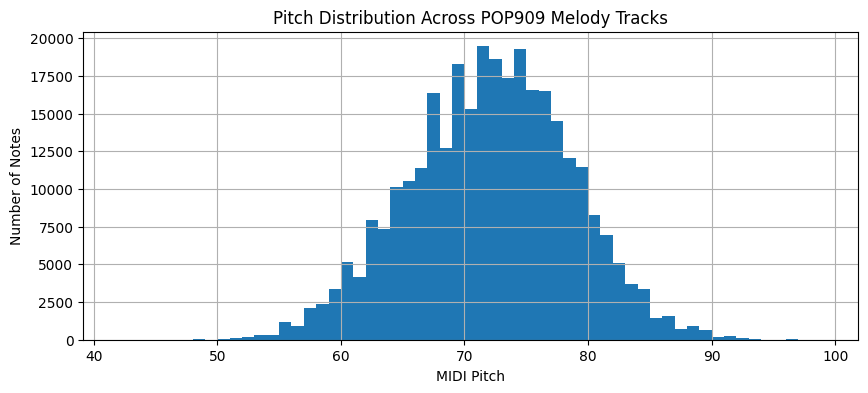

In [15]:
# Pitch distribution across all POP909 melody tracks

plt.figure(figsize=(10, 4))
all_notes_df["pitch"].hist(bins=range(
    all_notes_df["pitch"].min(),
    all_notes_df["pitch"].max() + 2
))
plt.title("Pitch Distribution Across POP909 Melody Tracks")
plt.xlabel("MIDI Pitch")
plt.ylabel("Number of Notes")
plt.show()

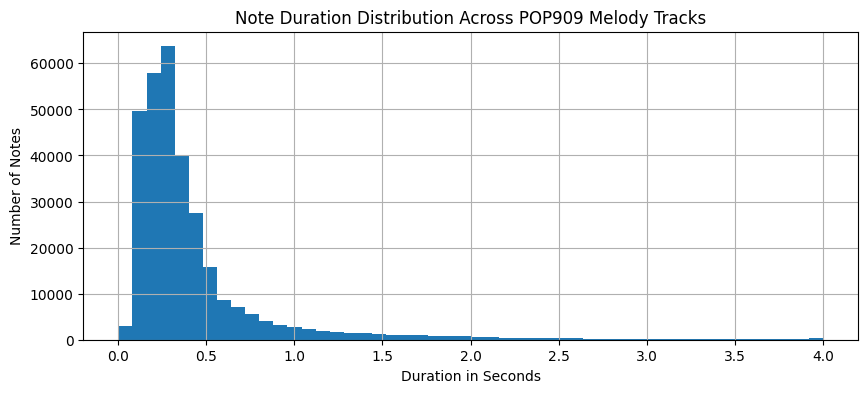

In [16]:
# Duration distribution across all POP909 melody tracks

plt.figure(figsize=(10, 4))
all_notes_df["duration"].clip(upper=4).hist(bins=50)
plt.title("Note Duration Distribution Across POP909 Melody Tracks")
plt.xlabel("Duration in Seconds")
plt.ylabel("Number of Notes")
plt.show()

### EDA Summary

We extracted 309,423 melody notes from the 909 main POP909 MIDI files. For this first version of the project, we use only the `MELODY` track from each song because it gives a simpler monophonic-style symbolic sequence for unconditioned melody generation.

The pitch distribution shows that most melody notes are concentrated around MIDI pitches 60–82, with an average pitch around 71.6. This suggests the melodies mostly stay in a practical pop-melody vocal/piano range instead of using the full MIDI pitch range.

The duration distribution shows that most notes are short, usually under 0.5 seconds, with a smaller number of longer notes. This matters for generation because the model needs to learn both pitch movement and rhythm/duration patterns, not just note order.

## 2. Modeling

### 2.1 Task Formulation

For symbolic unconditioned generation, the goal is to train a model that learns patterns from symbolic MIDI note sequences and generates a new melody without being given a seed melody, chord progression, or other input condition.

We formulate each song as a sequence of melody note events. Each event contains pitch and duration information. The model learns which events tend to follow other events in the POP909 melody tracks, then samples a new sequence from the learned distribution.

### 2.2 Convert Notes to Tokens

In [17]:
# Convert each melody note into a simple symbolic token.
# We quantize duration so the model learns pitch + approximate rhythm.

def quantize_duration(duration):
    if duration < 0.125:
        return "very_short"
    elif duration < 0.25:
        return "short"
    elif duration < 0.5:
        return "medium"
    elif duration < 1.0:
        return "long"
    else:
        return "very_long"

all_notes_df["duration_bin"] = all_notes_df["duration"].apply(quantize_duration)

all_notes_df["token"] = (
    "PITCH_" + all_notes_df["pitch"].astype(str) +
    "_DUR_" + all_notes_df["duration_bin"]
)

all_notes_df[["song_id", "pitch", "duration", "duration_bin", "token"]].head()

,song_id,pitch,duration,duration_bin,token
0,001,61,0.095833,very_short,PITCH_61_DUR_very_short
1,001,63,0.062500,very_short,PITCH_63_DUR_very_short
2,001,66,0.068055,very_short,PITCH_66_DUR_very_short
3,001,68,0.083333,very_short,PITCH_68_DUR_very_short
4,001,70,0.109722,very_short,PITCH_70_DUR_very_short


### 2.3 Build Song-Level Token Sequences

In [18]:
# Build one ordered token sequence per song.
# Each sequence is the melody track represented as pitch-duration tokens.

song_sequences = []

for song_id, group in all_notes_df.groupby("song_id"):
    group = group.sort_values("start")
    tokens = group["token"].tolist()
    
    if len(tokens) > 1:
        song_sequences.append(tokens)

print("Number of song sequences:", len(song_sequences))
print("Length of first sequence:", len(song_sequences[0]))
print("First 10 tokens:")
print(song_sequences[0][:10])

Number of song sequences: 909
Length of first sequence: 264
First 10 tokens:
['PITCH_61_DUR_very_short', 'PITCH_63_DUR_very_short', 'PITCH_66_DUR_very_short', 'PITCH_68_DUR_very_short', 'PITCH_70_DUR_very_short', 'PITCH_66_DUR_short', 'PITCH_63_DUR_short', 'PITCH_68_DUR_long', 'PITCH_68_DUR_short', 'PITCH_65_DUR_short']


### 2.4 Train an N-gram Transition Model

In [19]:
from collections import defaultdict, Counter

# We use a trigram-style model:
# Given the previous 2 tokens, learn the distribution over the next token.
N = 3

transition_counts = defaultdict(Counter)

for sequence in song_sequences:
    for i in range(len(sequence) - N + 1):
        context = tuple(sequence[i:i + N - 1])
        next_token = sequence[i + N - 1]
        transition_counts[context][next_token] += 1

print("Number of learned contexts:", len(transition_counts))

example_context = next(iter(transition_counts))
print("Example context:", example_context)
print("Possible next tokens:", transition_counts[example_context].most_common(10))

Number of learned contexts: 10900
Example context: ('PITCH_61_DUR_very_short', 'PITCH_63_DUR_very_short')
Possible next tokens: [('PITCH_66_DUR_very_short', 24), ('PITCH_66_DUR_medium', 4), ('PITCH_63_DUR_very_short', 4), ('PITCH_61_DUR_short', 4), ('PITCH_66_DUR_short', 3), ('PITCH_64_DUR_medium', 3), ('PITCH_65_DUR_medium', 2), ('PITCH_63_DUR_short', 2), ('PITCH_65_DUR_short', 2), ('PITCH_61_DUR_very_short', 1)]


### 2.5 Generate a New Melody Token Sequence

In [21]:
# Generate a new melody by sampling from the learned trigram transition model.
# Since this is unconditioned generation, we start from a random context learned from the dataset.

import random

def sample_next_token(next_token_counts):
    tokens = list(next_token_counts.keys())
    counts = np.array(list(next_token_counts.values()), dtype=float)
    probabilities = counts / counts.sum()
    return str(np.random.choice(tokens, p=probabilities))

def generate_token_sequence(transition_counts, length=200):
    # Randomly choose a learned context as the starting point.
    current_context = random.choice(list(transition_counts.keys()))
    generated = list(current_context)
    
    while len(generated) < length:
        context = tuple(generated[-(N - 1):])
        
        # If the context was never seen, restart from a random learned context.
        if context not in transition_counts:
            context = random.choice(list(transition_counts.keys()))
            generated.extend(list(context))
            continue
        
        next_token = sample_next_token(transition_counts[context])
        generated.append(next_token)
    
    return generated[:length]

generated_tokens = generate_token_sequence(transition_counts, length=200)

print("Generated token count:", len(generated_tokens))
print(generated_tokens[:20])

Generated token count: 200
['PITCH_72_DUR_short', 'PITCH_69_DUR_very_long', 'PITCH_69_DUR_medium', 'PITCH_72_DUR_medium', 'PITCH_72_DUR_medium', 'PITCH_72_DUR_short', 'PITCH_72_DUR_short', 'PITCH_68_DUR_short', 'PITCH_67_DUR_medium', 'PITCH_65_DUR_very_long', 'PITCH_60_DUR_medium', 'PITCH_62_DUR_medium', 'PITCH_60_DUR_long', 'PITCH_58_DUR_medium', 'PITCH_58_DUR_very_long', 'PITCH_65_DUR_medium', 'PITCH_68_DUR_medium', 'PITCH_70_DUR_long', 'PITCH_68_DUR_short', 'PITCH_68_DUR_long']


### 2.6 Convert Generated Tokens to MIDI

In [22]:
# Convert generated pitch-duration tokens back into a MIDI file.

from pathlib import Path

DURATION_SECONDS = {
    "very_short": 0.125,
    "short": 0.25,
    "medium": 0.5,
    "long": 1.0,
    "very_long": 2.0
}

def token_to_note_info(token):
    # Example token: "PITCH_61_DUR_very_short"
    parts = str(token).split("_DUR_")
    pitch = int(parts[0].replace("PITCH_", ""))
    duration_bin = parts[1]
    duration = DURATION_SECONDS[duration_bin]
    return pitch, duration

def tokens_to_midi(tokens, output_path, tempo=120):
    midi_out = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    
    # program=0 means Acoustic Grand Piano
    instrument = pretty_midi.Instrument(program=0, name="Generated Melody")
    
    current_time = 0.0
    
    for token in tokens:
        pitch, duration = token_to_note_info(token)
        
        note = pretty_midi.Note(
            velocity=100,
            pitch=pitch,
            start=current_time,
            end=current_time + duration
        )
        
        instrument.notes.append(note)
        current_time += duration
    
    midi_out.instruments.append(instrument)
    midi_out.write(str(output_path))

output_path = Path("outputs/symbolic_unconditioned.mid")
tokens_to_midi(generated_tokens, output_path)

print("Saved generated MIDI to:", output_path)

Saved generated MIDI to: outputs/symbolic_unconditioned.mid


In [23]:
# Verify the generated MIDI file can be loaded and inspected.

generated_midi = pretty_midi.PrettyMIDI("outputs/symbolic_unconditioned.mid")

print("Number of instruments:", len(generated_midi.instruments))
print("Generated notes:", len(generated_midi.instruments[0].notes))
print("Duration in seconds:", generated_midi.get_end_time())

Number of instruments: 1
Generated notes: 200
Duration in seconds: 109.625


In [24]:
# Create a faster version by shortening generated note durations.

FAST_DURATION_SECONDS = {
    "very_short": 0.08,
    "short": 0.16,
    "medium": 0.32,
    "long": 0.64,
    "very_long": 1.28
}

def token_to_note_info_fast(token):
    parts = str(token).split("_DUR_")
    pitch = int(parts[0].replace("PITCH_", ""))
    duration_bin = parts[1]
    duration = FAST_DURATION_SECONDS[duration_bin]
    return pitch, duration

def tokens_to_fast_midi(tokens, output_path, tempo=140):
    midi_out = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=0, name="Generated Melody Fast")
    
    current_time = 0.0
    
    for token in tokens:
        pitch, duration = token_to_note_info_fast(token)
        
        note = pretty_midi.Note(
            velocity=100,
            pitch=pitch,
            start=current_time,
            end=current_time + duration
        )
        
        instrument.notes.append(note)
        current_time += duration
    
    midi_out.instruments.append(instrument)
    midi_out.write(str(output_path))

fast_output_path = Path("outputs/symbolic_unconditioned_fast.mid")
tokens_to_fast_midi(generated_tokens, fast_output_path)

print("Saved faster generated MIDI to:", fast_output_path)

Saved faster generated MIDI to: outputs/symbolic_unconditioned_fast.mid


### Modeling Summary

For this first symbolic unconditioned generation model, we represented each melody as a sequence of pitch-duration tokens. Each token stores the MIDI pitch and a quantized duration category. We then trained a trigram transition model, where the model learns the distribution of the next token given the previous two tokens.

Generation is unconditioned because the model does not receive a seed melody, chord progression, or external prompt. Instead, generation begins from a randomly selected context learned from the training data, and the model repeatedly samples the next token from the learned transition probabilities.

The generated token sequence is converted back into a MIDI file by mapping each pitch-duration token into a MIDI note event.

## 3. Evaluation

### Evaluation Goals

### Baselines

### Metrics and Results

## 4. Discussion of Related Work

### Related Datasets

### Related Methods

### Comparison to Our Results

# Task 2: Remix Central

## 1. Exploratory Analysis, Data Collection, Pre-processing, and Discussion

### Dataset Context

### Pre-processing

### Exploratory Analysis

## 2. Modeling

### Task Formulation

### Model Choice

### Implementation Details

## 3. Evaluation

### Evaluation Goals

### Baselines

### Metrics and Results

## 4. Discussion of Related Work

### Related Datasets

### Related Methods

### Comparison to Our Results